<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lecture 26: Machine Learning in the Geosciences
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences

## **1. The Geoscience Data Explosion**
Traditionally, geosciences relied on physically-based models (e.g., **Navier-Stokes** for oceanography or **Darcy’s Law** for groundwater). While accurate, these are computationally expensive. We are now in a "Data Deluge" era driven by:

* **Remote Sensing:** 24/7 multispectral "live streams" from satellites like Sentinel and Landsat.
* **In-Situ Networks:** The Earth is "wired" with seismic arrays (EarthScope) and ocean floats (Argo).
* **Subsurface Imaging:** 3D seismic and Fiber Optic Sensing (DAS) that turn entire cables into seismic sensors.

### **The "Four Vs" of Geoscience Data**
1.  **Volume:** Moving from megabytes to petabytes of satellite imagery.
2.  **Velocity:** Real-time data streams from GPS and earthquake monitoring.
3.  **Variety:** Mixing 1D logs, 2D maps, 3D volumes, and 4D time-series.
4.  **Veracity:** Using ML to handle the "messiness" and noise of natural systems.

In [6]:
# --- INITIAL SETUP & LIBRARIES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans

# Plotting settings
sns.set_theme(style="whitegrid")
%matplotlib inline
print("Libraries loaded. Ready for Geoscience ML.")

Libraries loaded. Ready for Geoscience ML.


## **2. Supervised Learning: Random Forest**
**Classification** assigns data to specific categories.
* **Lecture Example:** A Random Forest was used to detect if a seismic wave is being recorded on a GNSS station and estimate its arrival time.
* **Our Example:** Predicting Rock Types (Lithology) based on geochemical assays (Silica, Iron, and Magnesium content).



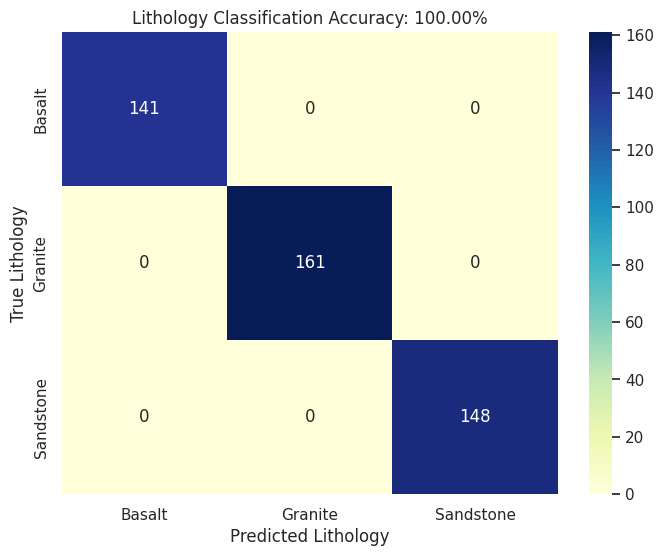

In [7]:
# Simulating a Geochemical Dataset
np.random.seed(42)
n = 500
# Features: [Silica %, Iron %, Magnesium %]
basalt = np.random.normal([48, 11, 9], 2, (n, 3))
granite = np.random.normal([72, 3, 1], 2, (n, 3))
sandstone = np.random.normal([85, 1, 0.5], 2, (n, 3))

X = np.vstack([basalt, granite, sandstone])
y = np.array(['Basalt']*n + ['Granite']*n + ['Sandstone']*n)

# Split into Training (70%) and Testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Visualize Results with a Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title(f"Lithology Classification Accuracy: {accuracy_score(y_test, y_pred):.2%}")
plt.ylabel("True Lithology")
plt.xlabel("Predicted Lithology")
plt.show()

## **3. Neural Networks (Deep Learning)**
Neural Networks use layers of "neurons" to model non-linear Earth systems.
* **Weights (w) & Biases (b):** The parameters the model adjusts to learn.
* **Activation Functions:** (e.g., ReLU) allow the model to capture sudden changes, like earthquake onsets.
* **The Loss Landscape:** Training is like finding the lowest point in a foggy mountain range using **Gradient Descent**.

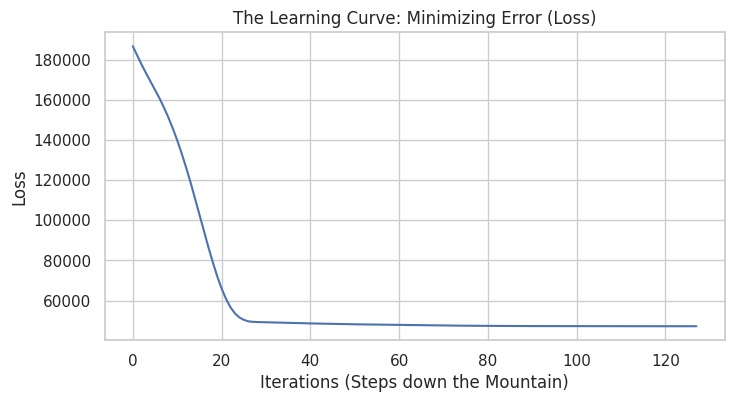

In [8]:
# Implementing a Multi-Layer Perceptron (MLP)
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
mlp.fit(X_train, np.arange(len(y_train))) # Using dummy index for regression demonstration

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title("The Learning Curve: Minimizing Error (Loss)")
plt.xlabel("Iterations (Steps down the Mountain)")
plt.ylabel("Loss")
plt.show()

## **4. Unsupervised Learning: K-Means**
In many geoscience scenarios, we don't have "labels" (we can't see 5km underground). Unsupervised learning finds natural clusters in "Dark Data" to identify different geological units or seismic regimes automatically.

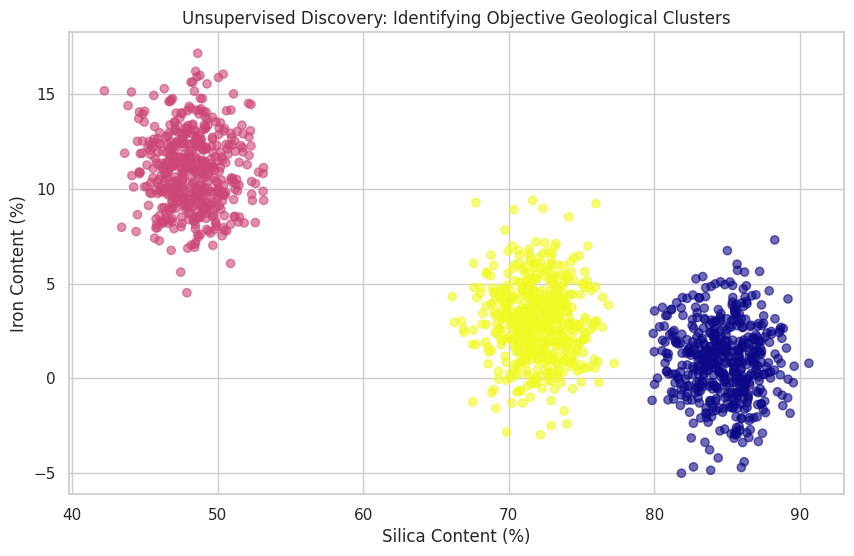

In [9]:
# Using K-Means to find groups in our Geochemical data without using labels
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='plasma', alpha=0.6)
plt.title("Unsupervised Discovery: Identifying Objective Geological Clusters")
plt.xlabel("Silica Content (%)")
plt.ylabel("Iron Content (%)")
plt.show()

## **5. Specialized Architectures**
* **CNNs (Convolutional):** The "Eyes" of ML—best for satellite images and seismic volumes.
* **RNNs/LSTMs (Recurrent):** The "Memory"—best for time-series like streamflow or volcanic tremor.
* **PINNs (Physics-Informed):** The "Scientists"—ML that obeys physical laws (e.g., ensuring gravity always pulls down).